<a href="https://colab.research.google.com/github/trongphuoc293-del/GPA/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir='/content/drive/MyDrive/Colab Notebooks/Ảnh Lớp IC'
img_width,img_height=280,280
batch_size=32

train_data=ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    shear_range=0.2,
    zoom_range=0.2,
    height_shift_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [8]:
train_generator=train_data.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1562 images belonging to 34 classes.


In [9]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',
           input_shape=(img_width,img_height,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
epochs=15
history=model.fit(train_generator,epochs=epochs)




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 138, 138, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 67, 67, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    17,842,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,939,938 (68.44 MB)

 Trainable params: 17,939,938 (68.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 666s 13s/step - accuracy: 0.0339 - loss: 3.6422
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.0768 - loss: 3.2474
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1530 - loss: 2.8426
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2343 - loss: 2.5263
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2868 - loss: 2.2714
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3399 - loss: 2.0969
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3841 - loss: 1.9714
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4232 - loss: 1.8520
Epoch 9/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4731 - loss: 1.6265
Epoch 10/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4955 - loss: 1.5441
Epoch 11/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5090 - loss: 1.5103
Epoch 12/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5557 - 

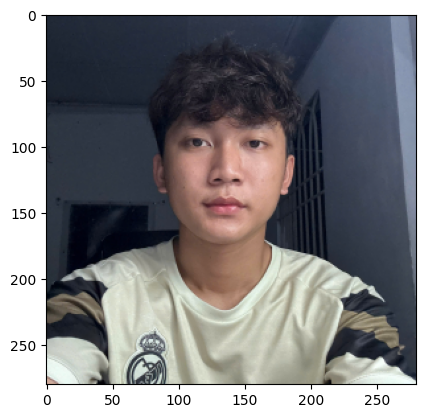

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
Người tiên đoán:BÙI VÕ THUẬT


In [11]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path='/content/drive/MyDrive/Colab Notebooks/Ảnh Lớp IC/BÙI VÕ THUẬT/z7869354384535_7a9580ecbe9b69a30c18bfe6a42bb51d.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
person_name=class_labels[prediction]
print(f"Người tiên đoán:{person_name}")

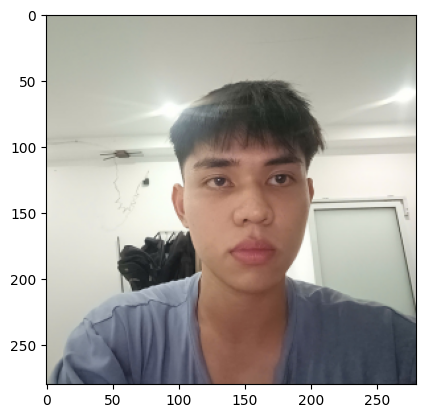

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Người tiên đoán:Võ Thiên Bảo


In [17]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path='/content/drive/MyDrive/Colab Notebooks/Ảnh Lớp IC/Văn Hoàng/3500.png'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/225.0
img=img.reshape(1,280,280,3)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
person_name=class_labels[prediction]
print(f"Người tiên đoán:{person_name}")